Bước 1: Chọn Upload rồi upload video sample lên, đặt tên folder là input_videos<br>
Bước 2: Upload 2 model lên, đặt tên folder là models<br>
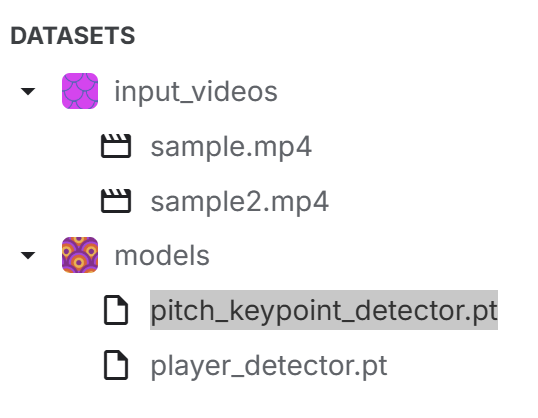<br>
Link chứa video sample và models: https://drive.google.com/drive/u/0/folders/10kMuVXpLO2qYchwApMiravQzKX2H_E2E<br>
Bước 3: Đổi thời gian chạy sang GPU T4

Clone dự án:

In [ ]:
!git clone https://github.com/henruysun2511/football_tracking.git
# 1. Di chuyển vào thư mục dự án trên Kaggle
%cd /kaggle/working/football_tracking

# 2. Reset file main.py về bản sạch từ GitHub
# !git checkout main.py

Chạy test không giao diện:

In [ ]:
!pip install -r requirements.txt

In [ ]:
import os
print("Video chuẩn chưa:", os.path.exists('/kaggle/input/datasets/huysun/input-videos/sample2.mp4'))
print("Model 1 chuẩn chưa:", os.path.exists('/kaggle/input/datasets/huysun/models/player_detector.pt'))
print("Model 2 chuẩn chưa:", os.path.exists('/kaggle/input/datasets/huysun/models/pitch_keypoint_detector.pt'))

In [ ]:
Điền nickname vào đây

In [ ]:
!sed -i 's|huysun|yournickname|g' main.py

In [ ]:
!git pull
!rm -rf stubs
!python main.py --mode tracking

In [ ]:
!python main.py --mode render

In [ ]:
%cd /kaggle/working/football_tracking

# 1. Convert video từ .avi sang .mp4 chuẩn H.264 để trình duyệt đọc được
!ffmpeg -i output_videos/output_enhanced.avi -c:v libx264 -preset fast -crf 23 output_videos/output_enhanced.mp4 -y

# 2. Hiển thị video lên màn hình Kaggle
from IPython.display import Video, display
display(Video("output_videos/output_enhanced.mp4", embed=True, width=800))

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Hiển thị ảnh heatmap tổng hợp của cả 2 đội
img = Image.open('output_videos/heatmap_both.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

Chạy giao diện web: <br>
Thay huysun thành tên nick của bạn

In [ ]:
# 1. Di chuyển vào thư mục dự án
%cd /kaggle/working/football_tracking

# 2. Tạo liên kết mềm tới Models trong Dataset
!mkdir -p models
!ln -sf /kaggle/input/datasets/huysun/models/player_detector.pt models/player_detector.pt
!ln -sf /kaggle/input/datasets/huysun/models/pitch_keypoint_detector.pt models/pitch_keypoint_detector.pt

# 3. Thuật toán tự động tìm kiếm file chứa hàm ghi video để sửa cấu hình nén sang MP4 chuẩn
import os
from pathlib import Path

target_dir = Path("/kaggle/working/football_tracking/utils")
for py_file in target_dir.glob("**/*.py"):
    content = py_file.read_text()
    if "VideoWriter_fourcc" in content:
        print(f"-> Phát hiện cấu hình nén video tại: {py_file.name}")
        content = content.replace("XVID", "mp4v").replace("MJPG", "mp4v").replace(".avi", ".mp4")
        py_file.write_text(content)

# 4. Clear cache cũ
!rm -rf cache_gradio/*

# 5. Khởi động ứng dụng công khai
!python app/gradio_app.py

Lưu ý chỉ chạy 1 trong 2 trong một session nếu không sẽ bị runtime error không đủ bộ nhớ